In [1]:
import pandas as pd

from unibench.benchmarks_zoo.registry import list_benchmarks
from unibench.models_zoo.registry import list_models
from unibench.output import OutputHandler
import seaborn as sns
import matplotlib.pyplot as plt

# models = list_models('vllm') + ['siglip2_so400_16_512']
models = list_models('vllm')

benchmarks = list_benchmarks()

outputhandler = OutputHandler(output_dir='/home/haltahan6/unibench/outputs', download_all_precomputed=False)

outputhandler.load_all_csv(
    model_name=models,
    benchmark_name=benchmarks,
)

results = outputhandler.query(**{"benchmark_name": benchmarks, "model_name": models})
from unibench.common_utils.utils import get_model_mappings
model_mappings = get_model_mappings('name')
results['model_name'] = results["model_name"].map(model_mappings)

from unibench.common_utils.utils import get_benchmark_mappings
benchmark_mappings = get_benchmark_mappings("capability")
results["capability"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("benchmark_type")
results["benchmark_type"] = results["benchmark_name"].map(benchmark_mappings)
benchmark_mappings = get_benchmark_mappings("num_classes")
results["num_classes"] = results["benchmark_name"].map(benchmark_mappings)

results = results[(results['task_name'] == 'multi_choice_classification')]

/home/haltahan6/anaconda3/envs/vllm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/sugarcrepe.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_attribution.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/vg_relation.f
File not found:  /home/haltahan6/unibench/outputs/chameleon_30b/winoground.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/bivlc.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/caltech101.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cars.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar10.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/cifar100.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_count.f
File not found:  /home/haltahan6/unibench/outputs/llama_3_2_90b_vision_instruct/clevr_distance.f
File not found:  /home/haltahan6/unibench/outpu

In [2]:
results.model_name.unique()

array(['Aya Vision 32B', 'Aya Vision 8B', 'Chameleon 30B', 'Chameleon 7B',
       'Gemma 3 27B', 'Gemma 3 4B', 'Llama 3.2 11B Vision Instruct',
       'Llava 1.5 13B', 'Llava 1.5 7B', 'Llava 1.6 Mistral 7B',
       'Llava 1.6 Vicuna 13B', 'Llava 1.6 Vicuna 7B',
       'Llava Next Llama 3 8B', 'PaliGemma 2 10B Mix 224',
       'PaliGemma 2 10B Mix 448', 'PaliGemma 2 28B Mix 224',
       'PaliGemma 2 28B Mix 448', 'PaliGemma 2 3B Mix 224',
       'PaliGemma 2 3B Mix 448', 'PaliGemma 3B 224', 'PaliGemma 3B 448',
       'PaliGemma 3B Mix 224'], dtype=object)

In [3]:
import re

def check_model_output_format(model_output):
    """
    Check if model output follows the correct multiple choice format.
    Returns a score between 0 and 1 based on format compliance.
    """
    if pd.isna(model_output) or model_output == '':
        return 0.0
    
    # Convert to string and clean
    output = str(model_output).strip()
    
    # Check for exact single letter format (A, B, C, or D)
    single_letter_pattern = r'^[ABCD]$'
    if re.match(single_letter_pattern, output):
        return 1.0
    
    # Check for parentheses format (A), (B), (C), (D)
    parentheses_pattern = r'^\([ABCD]\)$'
    if re.match(parentheses_pattern, output):
        return 1.0
    
    # Check for bolded format **A**, **B**, etc.
    bold_pattern = r'^\*\*[ABCD]\*\*$'
    if re.match(bold_pattern, output):
        return 1.0
    
    # Check if contains multiple valid answers (invalid)
    valid_answers = re.findall(r'[ABCD]', output)
    if len(valid_answers) > 1:
        return 0.0
    
    # Check if contains one valid answer but with extra text
    if len(valid_answers) == 1:
        return 0.5
    
    # No valid answer found
    return 0.0

# Apply the function to each model
format_scores = []

for model in results['model_name'].unique():
    model_data = results[results['model_name'] == model].copy()
    model_data['format_score'] = model_data['model_output'].apply(check_model_output_format)
    
    format_scores.append({
        'model_name': model,
        'total_responses': len(model_data),
        'perfect_format': (model_data['format_score'] == 1.0).sum(),
        'partial_format': (model_data['format_score'] == 0.5).sum(),
        'invalid_format': (model_data['format_score'] == 0.0).sum(),
        'avg_format_score': model_data['format_score'].mean()
    })

format_compliance_df = pd.DataFrame(format_scores)
format_compliance_df = format_compliance_df.sort_values('avg_format_score', ascending=False)
print(format_compliance_df)

                       model_name  total_responses  perfect_format  \
21           PaliGemma 3B Mix 224           212722          212721   
18         PaliGemma 2 3B Mix 448           425444          425441   
13        PaliGemma 2 10B Mix 224           212722          212716   
15        PaliGemma 2 28B Mix 224           212722          212467   
7                   Llava 1.5 13B           212722          211035   
14        PaliGemma 2 10B Mix 448           212722          208280   
17         PaliGemma 2 3B Mix 224           212722          200639   
16        PaliGemma 2 28B Mix 448           212722          191939   
12          Llava Next Llama 3 8B           212722          182618   
8                    Llava 1.5 7B           212722          177603   
11            Llava 1.6 Vicuna 7B           212722          132224   
9            Llava 1.6 Mistral 7B           212722          121597   
10           Llava 1.6 Vicuna 13B           212722          104782   
20               Pal

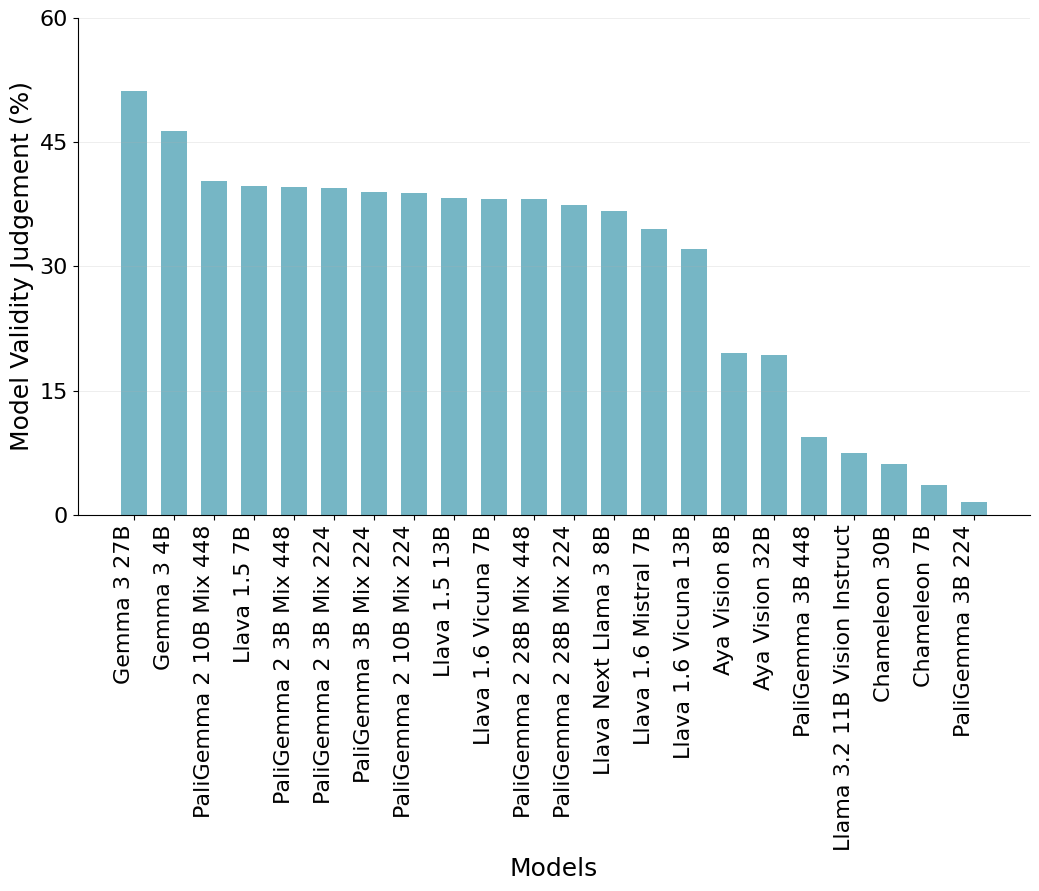

Model Accuracy Rankings (percent):
                       model_name   accuracy  total_samples
0                     Gemma 3 27B  51.160560         214724
1                      Gemma 3 4B  46.311618         212722
2         PaliGemma 2 10B Mix 448  40.378052         212722
3                    Llava 1.5 7B  39.675257         212722
4          PaliGemma 2 3B Mix 448  39.580767         425444
5          PaliGemma 2 3B Mix 224  39.524356         212722
6            PaliGemma 3B Mix 224  38.957419         212722
7         PaliGemma 2 10B Mix 224  38.861989         212722
8                   Llava 1.5 13B  38.232999         212722
9             Llava 1.6 Vicuna 7B  38.191160         212722
10        PaliGemma 2 28B Mix 448  38.153082         212722
11        PaliGemma 2 28B Mix 224  37.443706         212722
12          Llava Next Llama 3 8B  36.741851         212722
13           Llava 1.6 Mistral 7B  34.530044         212722
14           Llava 1.6 Vicuna 13B  32.055923         212722
15   

In [14]:
# --- Styling (same as above) ---
LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 16
TITLE_FONT_SIZE = 20
ANNOTATION_FONT_SIZE = 12

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate accuracy (%) for each model
accuracy_scores = []
for model in results['model_name'].unique():
    model_data = results[results['model_name'] == model]
    acc = model_data['correctness'].mean() * 100.0
    accuracy_scores.append({
        'model_name': model,
        'accuracy': acc,
        'total_samples': len(model_data)
    })

accuracy_df = (
    pd.DataFrame(accuracy_scores)
    .sort_values('accuracy', ascending=False)
    .reset_index(drop=True)
)

# --- Plot (Matplotlib only; match style) ---
COLOR_BARS = '#76B6C5'  # same teal tone used before

x = np.arange(len(accuracy_df), dtype=float)

fig, ax = plt.subplots(figsize=(10.5, 6.5))

bars = ax.bar(
    x,
    accuracy_df['accuracy'].values,
    color=COLOR_BARS,
    edgecolor='none',
    width=0.65
)
# Labels & ticks
ax.set_xlabel('Models', fontsize=LABEL_FONT_SIZE)
ax.set_ylabel('Model Validity Judgement (%)', fontsize=LABEL_FONT_SIZE)
ax.set_xticks(x)
ax.set_xticklabels(
    accuracy_df['model_name'],
    fontsize=TICK_FONT_SIZE,
    rotation=90,
    ha='right',
    # rotation_mode='anchor'
)

# Move labels to the left by adjusting their position
for i, label in enumerate(ax.get_xticklabels()):
    label.set_x(i + 0.2)  # Move each label slightly to the left
ax.tick_params(axis='y', labelsize=TICK_FONT_SIZE)

# Light y-grid and clean spines
ax.yaxis.grid(True, linestyle='-', linewidth=0.6, alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Nice y-limits / ticks (0 to rounded-up max with ~4 intervals)
ymax = float(np.nanmax(accuracy_df['accuracy'].values)) if len(accuracy_df) else 100
upper = max(10, np.ceil((ymax + 5) / 10) * 10)  # round up to nearest 10
ax.set_ylim(0, upper)
ax.set_yticks(np.linspace(0, upper, 5))

# Title
# ax.set_title('Model Performance: Accuracy Across All Benchmarks',
#              fontsize=TITLE_FONT_SIZE, weight='bold', pad=8)

# Value labels on bars
# for rect in bars:
#     h = rect.get_height()
#     ax.text(
#         rect.get_x() + rect.get_width()/2.0,
#         h + 0.8,                     # small gap above bar
#         f'{h:.1f}%',
#         ha='center', va='bottom',
#         fontsize=ANNOTATION_FONT_SIZE
#     )



# Offset them slightly to the right


plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

# Display the accuracy dataframe
print("Model Accuracy Rankings (percent):")
print(accuracy_df)